In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark.sql.functions as F

In [2]:
df = spark.read.table('datacollection.alpha_vantage.company_overview')

In [3]:
df.limit(2).show()

+------+------------+--------------------+--------------------+------+--------+--------+-------+----------+--------------------+--------------------+--------------------+-------------+-------------+--------------------+------------+-------+--------+---------+----------------+-------------+----+------------------+------------+------------------+-----------------+-----------------+------------+--------------+-------------+--------------------------+-------------------------+------------------+----------------------+----------------+-----------------+-----------------+-----------------------+----------+---------+--------------------+----------------+-----------+----------+-----+----------+---------+------------------+-------------------+-----------------+------------+--------------+--------------------+
|Symbol|   AssetType|                Name|         Description|   CIK|Exchange|Currency|Country|    Sector|            Industry|             Address|        OfficialSite|FiscalYearEnd|Late

In [4]:
print(f"Shape: ({df.count()}, {len(df.columns)})")

Shape: (23, 53)


In [5]:
df.printSchema()

root
 |-- Symbol: string (nullable = true)
 |-- AssetType: string (nullable = true)
 |-- Name: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- CIK: string (nullable = true)
 |-- Exchange: string (nullable = true)
 |-- Currency: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Sector: string (nullable = true)
 |-- Industry: string (nullable = true)
 |-- Address: string (nullable = true)
 |-- OfficialSite: string (nullable = true)
 |-- FiscalYearEnd: string (nullable = true)
 |-- LatestQuarter: string (nullable = true)
 |-- MarketCapitalization: long (nullable = true)
 |-- EBITDA: long (nullable = true)
 |-- PERatio: float (nullable = true)
 |-- PEGRatio: float (nullable = true)
 |-- BookValue: float (nullable = true)
 |-- DividendPerShare: float (nullable = true)
 |-- DividendYield: float (nullable = true)
 |-- EPS: float (nullable = true)
 |-- RevenuePerShareTTM: float (nullable = true)
 |-- ProfitMargin: float (nullable = true)
 |-- Operati

# Capitalização de Mercado

In [13]:
(df.groupBy('Symbol')
           .agg(
               F.first(F.col('Name')).alias('Name'),
               F.first(F.col('MarketCapitalization')).alias('MarketCapitalization')
           )
).orderBy('MarketCapitalization', ascending=False).limit(10).show(truncate=False)

+------+---------------------------------+--------------------+
|Symbol|Name                             |MarketCapitalization|
+------+---------------------------------+--------------------+
|AAPL  |Apple Inc.                       |4167977927000       |
|KLAC  |KLA Corporation                  |324792254000        |
|IBM   |International Business Machines  |255301059000        |
|BA    |The Boeing Company               |171258675000        |
|RSG   |Republic Services Inc            |66575434000         |
|NTAP  |NetApp Inc                       |29867991000         |
|FSLR  |First Solar Inc                  |25688875000         |
|LSCC  |Lattice Semiconductor Corporation|19756532000         |
|TXT   |Textron Inc                      |15862152000         |
|PNR   |Pentair PLC                      |12349895000         |
+------+---------------------------------+--------------------+



In [ ]:
df_market_cap = (df.groupBy('Symbol')
                .agg(
                    F.first(F.col('Name')).alias('Name'),
                    F.first(F.col('MarketCapitalization')).alias('MarketCapitalization')
                )
).orderBy('MarketCapitalization', ascending=False).toPandas()

In [14]:
df_market_cap.head()

,Symbol,Name,MarketCapitalization
0,AAPL,Apple Inc.,4167977927000
1,KLAC,KLA Corporation,324792254000
2,IBM,International Business Machines,255301059000
3,BA,The Boeing Company,171258675000
4,RSG,Republic Services Inc,66575434000


/var/folders/m6/5gldbqjd7y97574965jjjdsw0000gn/T/ipykernel_33554/760380960.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


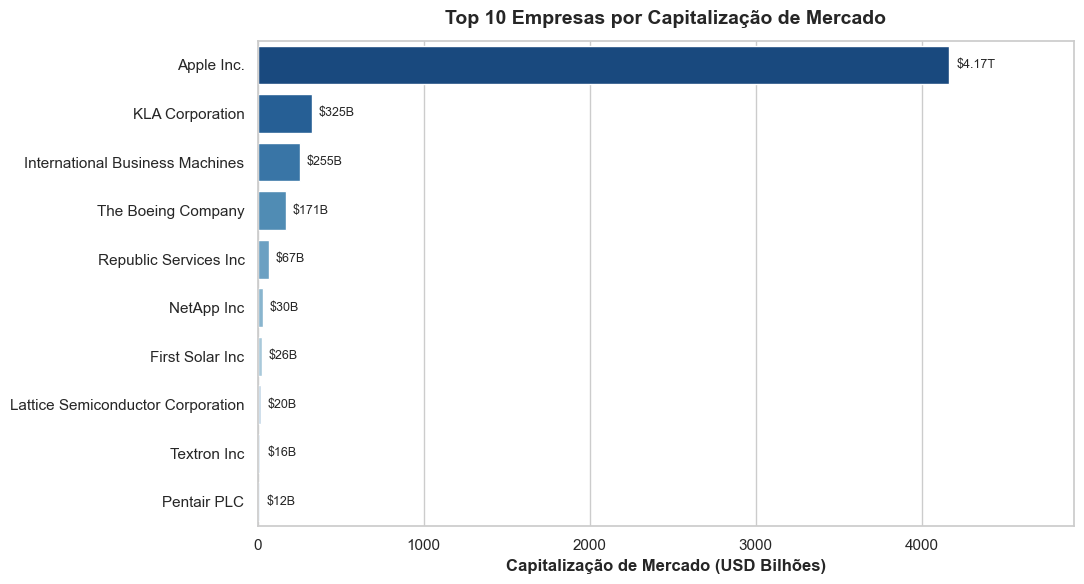

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')

top10 = df_market_cap.head(10).copy()
top10['MarketCap_B'] = top10['MarketCapitalization'] / 1e9

def fmt_cap(val_b):
    if val_b >= 1000:
        return f'${val_b / 1000:,.2f}T'
    return f'${val_b:,.0f}B'

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=top10,
    x='MarketCap_B',
    y='Name',
    palette='Blues_r',
    ax=ax,
)
ax.set_title('Top 10 Empresas por Capitalização de Mercado', fontweight='bold', fontsize=14, pad=12)
ax.set_xlabel('Capitalização de Mercado (USD Bilhões)', fontweight='bold', fontsize=12)
ax.set_ylabel('')

for bar, (_, row) in zip(ax.patches, top10.iterrows()):
    ax.text(
        bar.get_width() + top10['MarketCap_B'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        fmt_cap(row['MarketCap_B']),
        va='center', fontsize=9,
    )

ax.set_xlim(0, top10['MarketCap_B'].max() * 1.18)
plt.tight_layout()
plt.show()